In [1]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/sallyz/Library/CloudStorage/GoogleDrive-xz5105@nyu.edu/My Drive/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [2]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [3]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.3075337080446443),
 'd_ln_sigma_d_alpha': np.float64(2.783649426463509),
 'd_ln_sigma_d_beta': np.float64(-0.76719900840315),
 'd_ln_sigma_d_rho': np.float64(0.0047994361581260095),
 'd_ln_sigma_d_nu': np.float64(0.01778922843793641),
 'd_ln_sigma_d_forward': np.float64(-2.3980198155653882),
 'd_ln_sigma_d_strike': np.float64(0.8458659814736263),
 'd_ln_sigma_d_tte': np.float64(0.0075623430853099085),
 'd_ln_sigma_d_strike_strike': np.float64(14.983951453898316)}

In [4]:
# Question 1.2
# sensitivity of alpha w.r.t. sigma_LN_atm, beta, nu, rho, forward

# first get ATM lognormal vol from alpha
res_imp_log_normal_vol_atm = qfEuropeanOptionSABRLogNormalSigma(
    forward, forward, tte, alpha, beta, rho, nu, shift, True
)
sigma_ln_atm = res_imp_log_normal_vol_atm[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]

# then invert sigma_LN_atm -> alpha and compute sensitivities
res_alpha_from_atm_ln = qfEuropeanOptionSABRAlphaFromATMLogNormalSigma(
    forward, tte, sigma_ln_atm, beta, rho, nu, shift, True
)

display_res(res_alpha_from_atm_ln)


{'alpha': np.float64(0.11000000000000074),
 'd_alpha_d_ln_sigma_atm': np.float64(0.35741067861903947),
 'd_alpha_d_forward': np.float64(0.8404231867921418),
 'd_alpha_d_tte': np.float64(-0.0026948662467208497),
 'd_alpha_d_beta': np.float64(0.2769750258389835),
 'd_alpha_d_nu': np.float64(-0.00403509684808963),
 'd_alpha_d_rho': np.float64(0.00046387186249221494)}

In [5]:
# Question 1.3
# convert normal ATM vol to alpha, and compute sensitivities by chain rule

sigma_n_atm = 0.01  # example input

res_alpha_from_atm_n = qfEuropeanOptionSABRAlphaFromATMNormalSigma(
    forward=forward,
    time_to_expiry=tte,
    sigma_atm_normal=sigma_n_atm,
    beta=beta,
    rho=rho,
    nu=nu,
    shift=shift,
    calc_risk=True,
)

display_res(res_alpha_from_atm_n)


{'alpha': np.float64(0.04512794730889518),
 'd_alpha_d_normal_sigma_atm': np.float64(4.504901957643845),
 'd_alpha_d_beta': np.float64(0.11381956504085834),
 'd_alpha_d_nu': np.float64(-0.0013694587807423695),
 'd_alpha_d_rho': np.float64(0.0004898407759576584),
 'd_alpha_d_forward': np.float64(0.3988249010664792),
 'd_alpha_d_tte': np.float64(-0.0007636571228279281)}

In [6]:
res_sabr_normal = qfEuropeanOptionSABRNormal(
    forward,
    strike,
    tte,
    "call",
    sigma_n_atm,
    beta,
    rho,
    nu,
    shift,
    True,
)

display_res(res_sabr_normal)


{'pv': np.float64(0.002024290604111176),
 'delta': np.float64(0.38978123226632805),
 'gamma': np.float64(50.43263376358631),
 'theta': np.float64(-0.002809753199666045),
 'tte_risk': np.float64(0.002806743922224313),
 'strike_risk': np.float64(-0.3453297286161456),
 'dbeta': np.float64(3.4102952822891164e-05),
 'drho': np.float64(0.00012920015562512417),
 'dnu': np.float64(0.00014936490464786002),
 'strike_risk_2': np.float64(50.19636789560522),
 'dnormalsigma': np.float64(0.27350707473421165)}

# 2. Detection of Negative Density

The parameters set is:

In [7]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

In [8]:
# build a strictly positive lower-strike grid
# since shift = 0, strikes must stay positive
strikes = np.linspace(1e-4, forward * 0.999, 200)

# compute SABR pdf on the lower-strike grid
res_pdf = SABRAnalytics.pdf_and_cdf(
    forward=forward,
    time_to_expiry=tte,
    alpha=alpha,
    beta=beta,
    rho=rho,
    nu=nu,
    grids=strikes,
    shift=shift,
)

df_density = pd.DataFrame({
    "strike": res_pdf["grids"],
    "pdf": res_pdf["pdf"],
})

# detect negative density region
neg_density_df = df_density[df_density["pdf"] < 0].copy()

print("Minimum pdf:", df_density["pdf"].min())
print("Any negative density?", (df_density["pdf"] < 0).any())

if len(neg_density_df) > 0:
    print("\nStrikes with negative density:")
    display(neg_density_df)
else:
    print("\nNo negative density found on this lower-strike grid.")

display(df_density.head())


Minimum pdf: -393.081975085428
Any negative density? True

Strikes with negative density:


,strike,pdf
0,0.000100,-393.081975
1,0.000277,-393.081975
2,0.000454,-201.778341
3,0.000632,-132.370902
4,0.000809,-96.205570
5,0.000986,-74.074459
6,0.001163,-59.190939
7,0.001340,-48.532211
8,0.001518,-40.546557
9,0.001695,-34.355882


,strike,pdf
0,0.000100,-393.081975
1,0.000277,-393.081975
2,0.000454,-201.778341
3,0.000632,-132.370902
4,0.000809,-96.205570


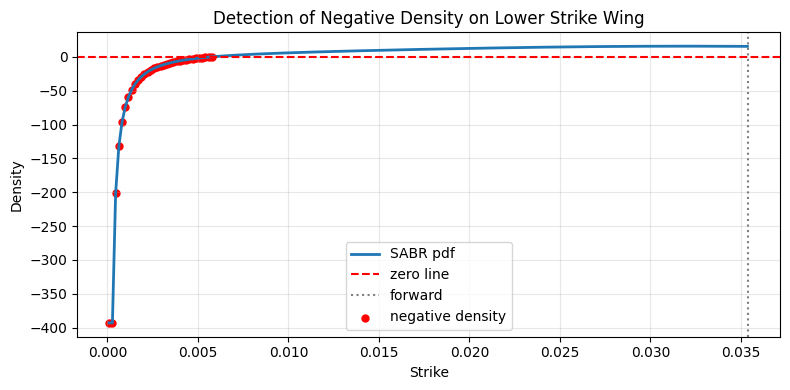

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(df_density["strike"], df_density["pdf"], lw=2, label="SABR pdf")
plt.axhline(0.0, color="red", linestyle="--", label="zero line")
plt.axvline(forward, color="gray", linestyle=":", label="forward")

if len(neg_density_df) > 0:
    plt.scatter(
        neg_density_df["strike"],
        neg_density_df["pdf"],
        color="red",
        s=25,
        label="negative density"
    )

plt.title("Detection of Negative Density on Lower Strike Wing")
plt.xlabel("Strike")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


At lower strikes, we can detect huge negative density of SABR.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fixed market setup
forward = 3.54 / 100
tte = 10.0
shift = 0.0

# lower-wing strike grid
strikes = np.linspace(1e-4, forward * 0.999, 200)

# parameter grids to scan
alpha_grid = [0.04, 0.0512, 0.06]
beta_grid = [0.25, 0.5, 0.75]
rho_grid = [-0.5, -0.095, 0.0, 0.5]
nu_grid = [0.1, 0.2, 0.322, 0.5, 0.8]

def detect_negative_density(forward, tte, alpha, beta, rho, nu, shift, strikes):
    try:
        res = SABRAnalytics.pdf_and_cdf(
            forward=forward,
            time_to_expiry=tte,
            alpha=alpha,
            beta=beta,
            rho=rho,
            nu=nu,
            grids=strikes,
            shift=shift,
        )

        pdf = np.asarray(res["pdf"], dtype=float)
        grids = np.asarray(res["grids"], dtype=float)

        neg_mask = pdf < 0
        has_negative = bool(np.any(neg_mask))
        min_pdf = float(np.min(pdf))
        min_pdf_strike = float(grids[np.argmin(pdf)])

        first_negative_strike = np.nan
        last_negative_strike = np.nan
        negative_count = int(np.sum(neg_mask))

        if has_negative:
            neg_strikes = grids[neg_mask]
            first_negative_strike = float(neg_strikes[0])
            last_negative_strike = float(neg_strikes[-1])

        return {
            "alpha": alpha,
            "beta": beta,
            "rho": rho,
            "nu": nu,
            "status": "ok",
            "has_negative_density": has_negative,
            "negative_count": negative_count,
            "min_pdf": min_pdf,
            "min_pdf_strike": min_pdf_strike,
            "first_negative_strike": first_negative_strike,
            "last_negative_strike": last_negative_strike,
            "error_msg": "",
        }

    except Exception as e:
        return {
            "alpha": alpha,
            "beta": beta,
            "rho": rho,
            "nu": nu,
            "status": "pricing_failed",
            "has_negative_density": False,
            "negative_count": np.nan,
            "min_pdf": np.nan,
            "min_pdf_strike": np.nan,
            "first_negative_strike": np.nan,
            "last_negative_strike": np.nan,
            "error_msg": str(e),
        }

# full scan
scan_results = []

for alpha in alpha_grid:
    for beta in beta_grid:
        for rho in rho_grid:
            for nu in nu_grid:
                row = detect_negative_density(
                    forward=forward,
                    tte=tte,
                    alpha=alpha,
                    beta=beta,
                    rho=rho,
                    nu=nu,
                    shift=shift,
                    strikes=strikes,
                )
                scan_results.append(row)

df_scan = pd.DataFrame(scan_results)

df_ok = df_scan[df_scan["status"] == "ok"].copy()
df_failed = df_scan[df_scan["status"] == "pricing_failed"].copy()
df_bad = df_ok[df_ok["has_negative_density"]].copy()

print("Total parameter sets tested:", len(df_scan))
print("Successful evaluations:", len(df_ok))
print("Pricing failed:", len(df_failed))
print("Negative density detected:", len(df_bad))

print("\nPricing-failed parameter sets:")
display(df_failed[["alpha", "beta", "rho", "nu", "error_msg"]])

print("\nParameter sets with negative density:")
display(
    df_bad.sort_values("min_pdf")[
        [
            "alpha",
            "beta",
            "rho",
            "nu",
            "min_pdf",
            "min_pdf_strike",
            "first_negative_strike",
            "last_negative_strike",
            "negative_count",
        ]
    ]
)


Total parameter sets tested: 180
Successful evaluations: 180
Pricing failed: 0
Negative density detected: 155

Pricing-failed parameter sets:


,alpha,beta,rho,nu,error_msg



Parameter sets with negative density:


,alpha,beta,rho,nu,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike,negative_count
158,0.0600,0.50,0.500,0.500,-713.217823,0.000277,0.0001,0.007543,43
98,0.0512,0.50,0.500,0.500,-710.292055,0.000277,0.0001,0.007543,43
157,0.0600,0.50,0.500,0.322,-641.636412,0.000277,0.0001,0.003113,18
119,0.0512,0.75,0.500,0.800,-566.982710,0.000277,0.0001,0.019416,110
179,0.0600,0.75,0.500,0.800,-563.055680,0.000277,0.0001,0.018530,105
...,...,...,...,...,...,...,...,...,...
47,0.0400,0.75,-0.095,0.322,-2.482412,0.000277,0.0001,0.000454,3
52,0.0400,0.75,0.000,0.322,-2.129932,0.000277,0.0001,0.000454,3
42,0.0400,0.75,-0.500,0.322,-1.196683,0.000100,0.0001,0.000277,2
117,0.0512,0.75,0.500,0.322,-0.888637,0.000277,0.0001,0.000454,3


In [11]:
print(df_bad)

     alpha  beta  rho     nu status  has_negative_density  negative_count  \
0     0.04  0.25 -0.5  0.100     ok                  True              91   
1     0.04  0.25 -0.5  0.200     ok                  True             107   
2     0.04  0.25 -0.5  0.322     ok                  True             128   
3     0.04  0.25 -0.5  0.500     ok                  True             156   
4     0.04  0.25 -0.5  0.800     ok                  True             184   
..     ...   ...  ...    ...    ...                   ...             ...   
173   0.06  0.75  0.0  0.500     ok                  True              52   
174   0.06  0.75  0.0  0.800     ok                  True             131   
177   0.06  0.75  0.5  0.322     ok                  True               3   
178   0.06  0.75  0.5  0.500     ok                  True              34   
179   0.06  0.75  0.5  0.800     ok                  True             105   

        min_pdf  min_pdf_strike  first_negative_strike  last_negative_strik

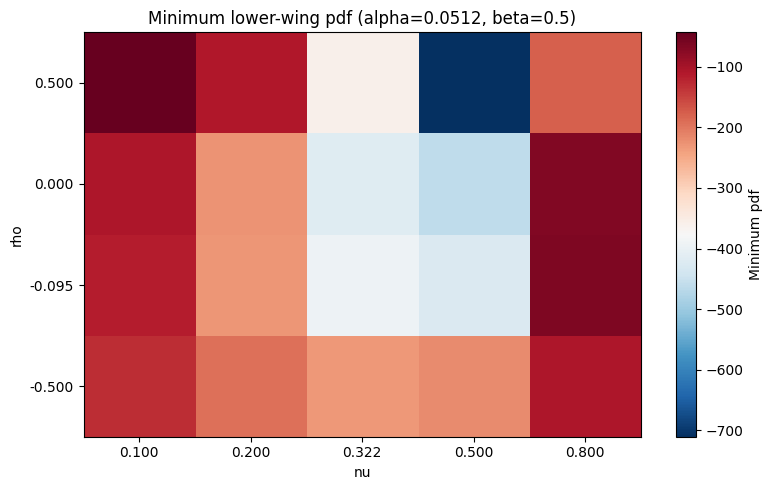

In [12]:
alpha_fix = 0.0512
beta_fix = 0.5

df_plot = df_ok[
    (df_ok["alpha"] == alpha_fix) &
    (df_ok["beta"] == beta_fix)
].copy()

pivot = df_plot.pivot(index="rho", columns="nu", values="min_pdf")

plt.figure(figsize=(8, 5))
im = plt.imshow(pivot.values, aspect="auto", origin="lower", cmap="RdBu_r")
plt.colorbar(im, label="Minimum pdf")
plt.xticks(range(len(pivot.columns)), [f"{x:.3f}" for x in pivot.columns])
plt.yticks(range(len(pivot.index)), [f"{x:.3f}" for x in pivot.index])
plt.xlabel("nu")
plt.ylabel("rho")
plt.title(f"Minimum lower-wing pdf (alpha={alpha_fix}, beta={beta_fix})")
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# baseline lower-wing parameter set
base_params = {
    "alpha": 0.0512,
    "beta": 0.5,
    "nu": 0.322,
    "rho": -9.5 / 100,
    "shift": 0.0,
    "forward": 3.54 / 100,
    "tte": 10.0,
}

# lower-wing strike grid
strikes = np.linspace(1e-4, base_params["forward"] * 0.999, 200)


def detect_negative_density_one_set(alpha, beta, rho, nu, forward, tte, shift, strikes):
    try:
        res = SABRAnalytics.pdf_and_cdf(
            forward=forward,
            time_to_expiry=tte,
            alpha=alpha,
            beta=beta,
            rho=rho,
            nu=nu,
            grids=strikes,
            shift=shift,
        )

        pdf = np.asarray(res["pdf"], dtype=float)
        grids = np.asarray(res["grids"], dtype=float)

        neg_mask = pdf < 0
        has_negative = bool(np.any(neg_mask))
        min_pdf = float(np.min(pdf))
        min_pdf_strike = float(grids[np.argmin(pdf)])
        negative_count = int(np.sum(neg_mask))

        first_negative_strike = np.nan
        last_negative_strike = np.nan

        if has_negative:
            neg_strikes = grids[neg_mask]
            first_negative_strike = float(neg_strikes[0])
            last_negative_strike = float(neg_strikes[-1])

        return {
            "status": "ok",
            "has_negative_density": has_negative,
            "negative_count": negative_count,
            "min_pdf": min_pdf,
            "min_pdf_strike": min_pdf_strike,
            "first_negative_strike": first_negative_strike,
            "last_negative_strike": last_negative_strike,
            "pdf_curve": pdf,
            "strike_curve": grids,
            "error_msg": "",
        }

    except Exception as e:
        return {
            "status": "pricing_failed",
            "has_negative_density": False,
            "negative_count": np.nan,
            "min_pdf": np.nan,
            "min_pdf_strike": np.nan,
            "first_negative_strike": np.nan,
            "last_negative_strike": np.nan,
            "pdf_curve": None,
            "strike_curve": None,
            "error_msg": str(e),
        }


def one_factor_scan(param_name, values, base_params, strikes):
    rows = []

    for v in values:
        params = base_params.copy()
        params[param_name] = float(v)

        res = detect_negative_density_one_set(
            alpha=params["alpha"],
            beta=params["beta"],
            rho=params["rho"],
            nu=params["nu"],
            forward=params["forward"],
            tte=params["tte"],
            shift=params["shift"],
            strikes=strikes,
        )

        row = {
            "parameter": param_name,
            "value": float(v),
            "alpha": params["alpha"],
            "beta": params["beta"],
            "rho": params["rho"],
            "nu": params["nu"],
            "forward": params["forward"],
            "tte": params["tte"],
            "status": res["status"],
            "has_negative_density": res["has_negative_density"],
            "negative_count": res["negative_count"],
            "min_pdf": res["min_pdf"],
            "min_pdf_strike": res["min_pdf_strike"],
            "first_negative_strike": res["first_negative_strike"],
            "last_negative_strike": res["last_negative_strike"],
            "error_msg": res["error_msg"],
            "pdf_curve": res["pdf_curve"],
            "strike_curve": res["strike_curve"],
        }
        rows.append(row)

    return pd.DataFrame(rows)


# one-factor-at-a-time ranges around the baseline
alpha_values = [0.03, 0.04, 0.0512, 0.06, 0.08]
beta_values = [0.1, 0.25, 0.5, 0.75, 0.9]
nu_values = [0.1, 0.2, 0.322, 0.5, 0.8]
rho_values = [-0.5, -0.25, -0.095, 0.0, 0.25, 0.5]

df_alpha = one_factor_scan("alpha", alpha_values, base_params, strikes)
df_beta = one_factor_scan("beta", beta_values, base_params, strikes)
df_nu = one_factor_scan("nu", nu_values, base_params, strikes)
df_rho = one_factor_scan("rho", rho_values, base_params, strikes)

print("Baseline parameter set:")
display(pd.DataFrame([base_params]))

print("\nAlpha scan:")
display(df_alpha[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nBeta scan:")
display(df_beta[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nNu scan:")
display(df_nu[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nRho scan:")
display(df_rho[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])


Baseline parameter set:


,alpha,beta,nu,rho,shift,forward,tte
0,0.0512,0.5,0.322,-0.095,0.0,0.0354,10.0



Alpha scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,0.0300,ok,True,21,-80.022418,0.000277,0.0001,0.003644
1,0.0400,ok,True,27,-209.620154,0.000277,0.0001,0.004707
2,0.0512,ok,True,33,-393.081975,0.000277,0.0001,0.005771
3,0.0600,ok,True,38,-521.031186,0.000277,0.0001,0.006657
4,0.0800,ok,True,53,-497.783966,0.000277,0.0001,0.009315



Beta scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,0.10,ok,True,162,-6.795909,0.032706,0.000277,0.035365
1,0.25,ok,True,155,-32.943269,0.006302,0.000277,0.027745
2,0.50,ok,True,33,-393.081975,0.000277,0.000100,0.005771
3,0.75,ok,True,5,-8.035413,0.000277,0.000100,0.000809
4,0.90,ok,False,0,0.621805,0.000277,NaN,NaN



Nu scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,0.100,ok,True,5,-115.733485,0.000277,0.0001,0.000809
1,0.200,ok,True,13,-230.363312,0.000277,0.0001,0.002227
2,0.322,ok,True,33,-393.081975,0.000277,0.0001,0.005771
3,0.500,ok,True,75,-424.114923,0.000277,0.0001,0.013213
4,0.800,ok,True,129,-66.319285,0.001518,0.0001,0.022783



Rho scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,-0.500,ok,True,40,-231.856751,0.000277,0.0001,0.007011
1,-0.250,ok,True,36,-342.113173,0.000277,0.0001,0.006302
2,-0.095,ok,True,33,-393.081975,0.000277,0.0001,0.005771
3,0.000,ok,True,30,-416.619491,0.000277,0.0001,0.005239
4,0.250,ok,True,23,-438.535051,0.000277,0.0001,0.003999
5,0.500,ok,True,16,-359.610152,0.000277,0.0001,0.002758


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# baseline lower-wing parameter set
base_params = {
    "alpha": 0.0512,
    "beta": 0.5,
    "nu": 0.322,
    "rho": -9.5 / 100,
    "shift": 0.0,
    "forward": 3.54 / 100,
    "tte": 10.0,
}

def build_lower_strike_grid(forward, n=200):
    return np.linspace(1e-4, forward * 0.999, n)

def detect_negative_density_one_set(alpha, beta, rho, nu, forward, tte, shift, strikes):
    try:
        res = SABRAnalytics.pdf_and_cdf(
            forward=forward,
            time_to_expiry=tte,
            alpha=alpha,
            beta=beta,
            rho=rho,
            nu=nu,
            grids=strikes,
            shift=shift,
        )

        pdf = np.asarray(res["pdf"], dtype=float)
        grids = np.asarray(res["grids"], dtype=float)

        neg_mask = pdf < 0
        has_negative = bool(np.any(neg_mask))
        min_pdf = float(np.min(pdf))
        min_pdf_strike = float(grids[np.argmin(pdf)])
        negative_count = int(np.sum(neg_mask))

        first_negative_strike = np.nan
        last_negative_strike = np.nan

        if has_negative:
            neg_strikes = grids[neg_mask]
            first_negative_strike = float(neg_strikes[0])
            last_negative_strike = float(neg_strikes[-1])

        return {
            "status": "ok",
            "has_negative_density": has_negative,
            "negative_count": negative_count,
            "min_pdf": min_pdf,
            "min_pdf_strike": min_pdf_strike,
            "first_negative_strike": first_negative_strike,
            "last_negative_strike": last_negative_strike,
            "pdf_curve": pdf,
            "strike_curve": grids,
            "error_msg": "",
        }

    except Exception as e:
        return {
            "status": "pricing_failed",
            "has_negative_density": False,
            "negative_count": np.nan,
            "min_pdf": np.nan,
            "min_pdf_strike": np.nan,
            "first_negative_strike": np.nan,
            "last_negative_strike": np.nan,
            "pdf_curve": None,
            "strike_curve": None,
            "error_msg": str(e),
        }

def one_factor_scan(param_name, values, base_params):
    rows = []

    for v in values:
        params = base_params.copy()
        params[param_name] = float(v)

        strikes = build_lower_strike_grid(params["forward"], n=200)

        res = detect_negative_density_one_set(
            alpha=params["alpha"],
            beta=params["beta"],
            rho=params["rho"],
            nu=params["nu"],
            forward=params["forward"],
            tte=params["tte"],
            shift=params["shift"],
            strikes=strikes,
        )

        row = {
            "parameter": param_name,
            "value": float(v),
            "alpha": params["alpha"],
            "beta": params["beta"],
            "rho": params["rho"],
            "nu": params["nu"],
            "forward": params["forward"],
            "tte": params["tte"],
            "status": res["status"],
            "has_negative_density": res["has_negative_density"],
            "negative_count": res["negative_count"],
            "min_pdf": res["min_pdf"],
            "min_pdf_strike": res["min_pdf_strike"],
            "first_negative_strike": res["first_negative_strike"],
            "last_negative_strike": res["last_negative_strike"],
            "error_msg": res["error_msg"],
            "pdf_curve": res["pdf_curve"],
            "strike_curve": res["strike_curve"],
        }
        rows.append(row)

    return pd.DataFrame(rows)

# one-factor-at-a-time ranges around the baseline
alpha_values = [0.03, 0.04, 0.0512, 0.06, 0.08]
beta_values = [0.1, 0.25, 0.5, 0.75, 0.9]
nu_values = [0.1, 0.2, 0.322, 0.5, 0.8]
rho_values = [-0.5, -0.25, -0.095, 0.0, 0.25, 0.5]
tte_values = [1.0, 2.0, 5.0, 10.0, 20.0, 30.0]

df_alpha = one_factor_scan("alpha", alpha_values, base_params)
df_beta = one_factor_scan("beta", beta_values, base_params)
df_nu = one_factor_scan("nu", nu_values, base_params)
df_rho = one_factor_scan("rho", rho_values, base_params)
df_tte = one_factor_scan("tte", tte_values, base_params)

print("Baseline parameter set:")
display(pd.DataFrame([base_params]))

print("\nAlpha scan:")
display(df_alpha[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nBeta scan:")
display(df_beta[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nNu scan:")
display(df_nu[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nRho scan:")
display(df_rho[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])

print("\nTTE scan:")
display(df_tte[[
    "value", "status", "has_negative_density", "negative_count",
    "min_pdf", "min_pdf_strike", "first_negative_strike", "last_negative_strike"
]])


Baseline parameter set:


,alpha,beta,nu,rho,shift,forward,tte
0,0.0512,0.5,0.322,-0.095,0.0,0.0354,10.0



Alpha scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,0.0300,ok,True,21,-80.022418,0.000277,0.0001,0.003644
1,0.0400,ok,True,27,-209.620154,0.000277,0.0001,0.004707
2,0.0512,ok,True,33,-393.081975,0.000277,0.0001,0.005771
3,0.0600,ok,True,38,-521.031186,0.000277,0.0001,0.006657
4,0.0800,ok,True,53,-497.783966,0.000277,0.0001,0.009315



Beta scan:


...

,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,0.100,ok,True,5,-115.733485,0.000277,0.0001,0.000809
1,0.200,ok,True,13,-230.363312,0.000277,0.0001,0.002227
2,0.322,ok,True,33,-393.081975,0.000277,0.0001,0.005771
3,0.500,ok,True,75,-424.114923,0.000277,0.0001,0.013213
4,0.800,ok,True,129,-66.319285,0.001518,0.0001,0.022783



Rho scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,-0.500,ok,True,40,-231.856751,0.000277,0.0001,0.007011
1,-0.250,ok,True,36,-342.113173,0.000277,0.0001,0.006302
2,-0.095,ok,True,33,-393.081975,0.000277,0.0001,0.005771
3,0.000,ok,True,30,-416.619491,0.000277,0.0001,0.005239
4,0.250,ok,True,23,-438.535051,0.000277,0.0001,0.003999
5,0.500,ok,True,16,-359.610152,0.000277,0.0001,0.002758



TTE scan:


,value,status,has_negative_density,negative_count,min_pdf,min_pdf_strike,first_negative_strike,last_negative_strike
0,1.0,ok,False,0,0.007203,0.000100,NaN,NaN
1,2.0,ok,False,0,1.016842,0.000809,NaN,NaN
2,5.0,ok,True,9,-52.945914,0.000277,0.0001,0.001518
3,10.0,ok,True,33,-393.081975,0.000277,0.0001,0.005771
4,20.0,ok,True,75,-340.020543,0.000277,0.0001,0.013213
5,30.0,ok,True,105,-73.542349,0.000809,0.0001,0.018530


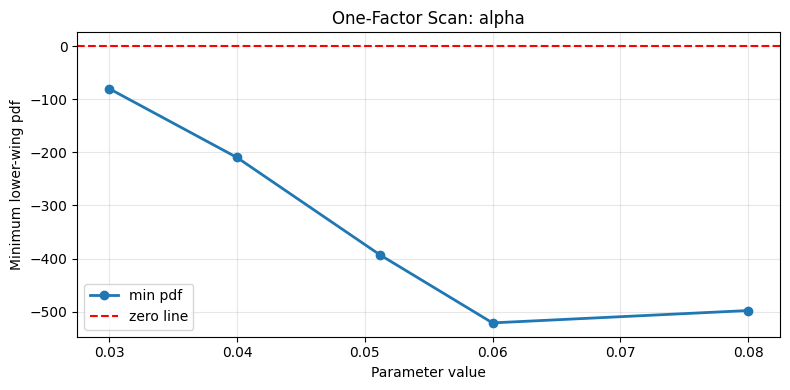

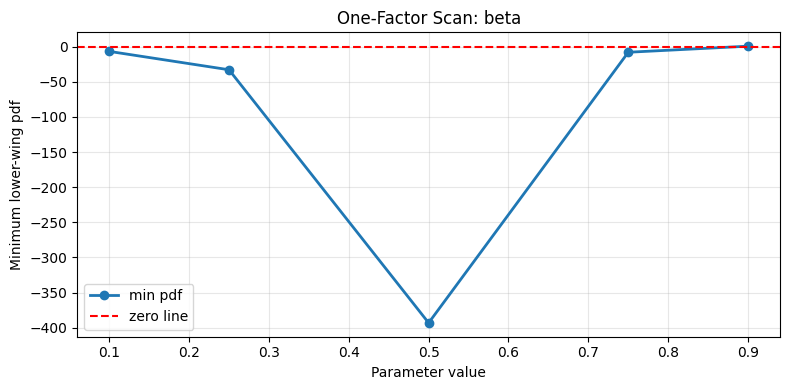

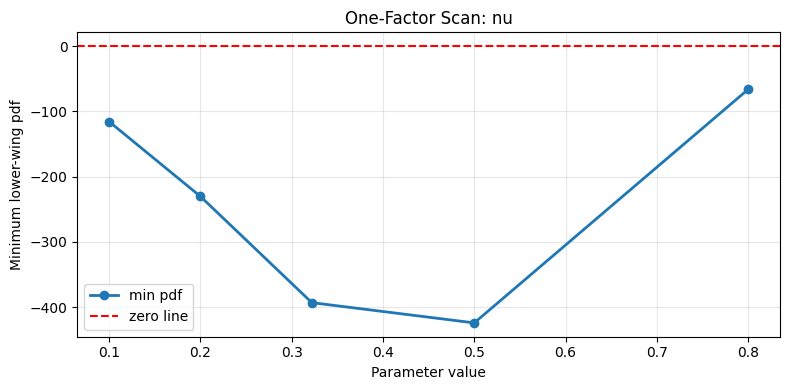

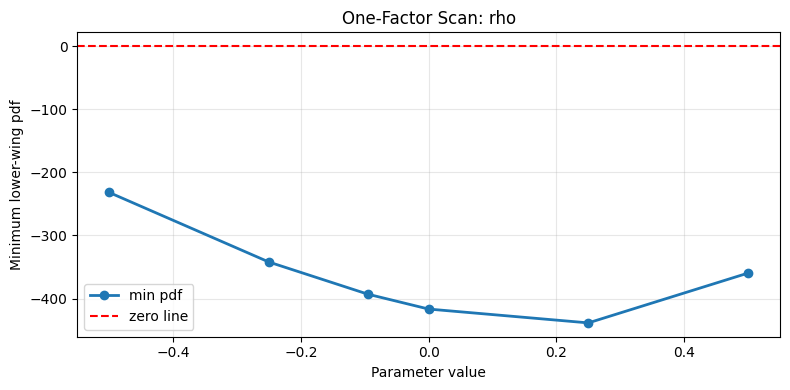

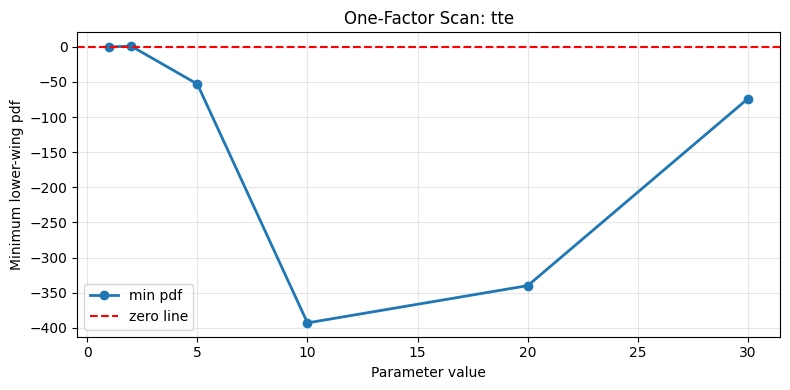

In [15]:
def plot_one_factor_scan(df, title):
    plt.figure(figsize=(8, 4))

    ok_df = df[df["status"] == "ok"].copy()
    fail_df = df[df["status"] == "pricing_failed"].copy()

    plt.plot(ok_df["value"], ok_df["min_pdf"], marker="o", lw=2, label="min pdf")
    plt.axhline(0.0, color="red", linestyle="--", label="zero line")

    if len(fail_df) > 0:
        plt.scatter(
            fail_df["value"],
            np.zeros(len(fail_df)),
            color="black",
            marker="x",
            s=60,
            label="pricing failed"
        )

    plt.title(title)
    plt.xlabel("Parameter value")
    plt.ylabel("Minimum lower-wing pdf")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_one_factor_scan(df_alpha, "One-Factor Scan: alpha")
plot_one_factor_scan(df_beta, "One-Factor Scan: beta")
plot_one_factor_scan(df_nu, "One-Factor Scan: nu")
plot_one_factor_scan(df_rho, "One-Factor Scan: rho")
plot_one_factor_scan(df_tte, "One-Factor Scan: tte")


# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

In [16]:
# experiment controls
step_size = 0.01
path_list = [5_000, 20_000, 100_000]
seed = 42

In [17]:
def sabr_call_price_via_european_options(forward, strike, tte, alpha, beta, rho, nu, shift):
    # SABR vol from sabr.py
    vol_res = SABRAnalytics.lognormal_vol_from_alpha(
        forward=forward,
        strike=strike,
        time_to_expiry=tte,
        alpha=alpha,
        beta=beta,
        rho=rho,
        nu=nu,
        shift=shift,
        calc_risk=False,
    )
    ln_vol = vol_res[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]

    # Black price from european_options.py
    price_res = EuropeanOptionAnalytics.european_option_log_normal(
        forward=forward + shift,
        strike=strike + shift,
        time_to_expiry=tte,
        log_normal_sigma=ln_vol,
        option_type=CallOrPut.CALL,
        calc_risk=False,
    )
    return price_res[SimpleMetrics.PV]


def sabr_pdf_bump_reval(forward, tte, alpha, beta, rho, nu, shift, strikes):
    strikes = np.asarray(strikes, dtype=float)
    call_prices = np.array(
        [
            sabr_call_price_via_european_options(forward, k, tte, alpha, beta, rho, nu, shift)
            for k in strikes
        ],
        dtype=float,
    )

    pdf = np.zeros_like(strikes)
    for i in range(1, len(strikes) - 1):
        h1 = strikes[i] - strikes[i - 1]
        h2 = strikes[i + 1] - strikes[i]
        pdf[i] = 2.0 * (
            call_prices[i - 1] / (h1 * (h1 + h2))
            - call_prices[i] / (h1 * h2)
            + call_prices[i + 1] / (h2 * (h1 + h2))
        )

    pdf[0] = pdf[1]
    pdf[-1] = pdf[-2]
    return call_prices, pdf


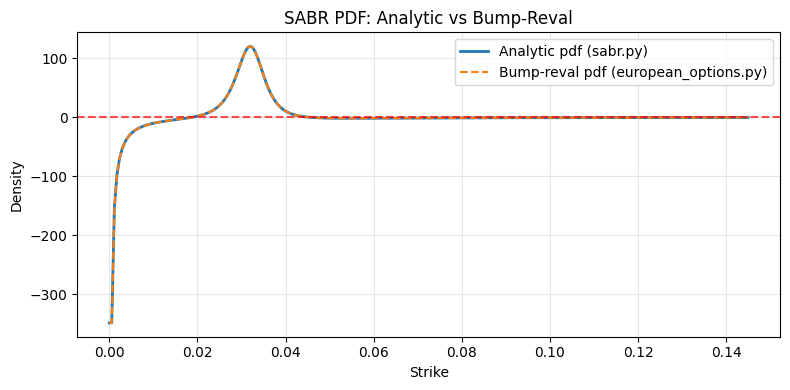

In [18]:
# 1) get a reference terminal sample to define plotting range
ref_sim = SABRAnalytics.simulate_terminal_distribution(
    forward=forward,
    time_to_expiry=tte,
    alpha=alpha,
    beta=beta,
    rho=rho,
    nu=nu,
    step_size=step_size,
    num_paths=max(path_list),
    shift=shift,
    seed=seed,
)
ref_terminal = np.asarray(ref_sim["terminal_forward"], dtype=float)

grid_min = max(1e-6, np.percentile(ref_terminal, 0.5))
grid_max = np.percentile(ref_terminal, 99.5)
pdf_grid = np.linspace(grid_min, grid_max, 250)

# 2) analytic SABR pdf from sabr.py
res_pdf = SABRAnalytics.pdf_and_cdf(
    forward=forward,
    time_to_expiry=tte,
    alpha=alpha,
    beta=beta,
    rho=rho,
    nu=nu,
    grids=pdf_grid,
    shift=shift,
)
analytic_pdf = np.asarray(res_pdf["pdf"], dtype=float)

# 3) bump-reval SABR pdf via european_options.py (optional cross-check)
_, bump_pdf = sabr_pdf_bump_reval(
    forward=forward,
    tte=tte,
    alpha=alpha,
    beta=beta,
    rho=rho,
    nu=nu,
    shift=shift,
    strikes=pdf_grid,
)

plt.figure(figsize=(8, 4))
plt.plot(pdf_grid, analytic_pdf, lw=2, label="Analytic pdf (sabr.py)")
plt.plot(pdf_grid, bump_pdf, lw=1.5, linestyle="--", label="Bump-reval pdf (european_options.py)")
plt.axhline(0.0, color="red", linestyle="--", alpha=0.7)
plt.title("SABR PDF: Analytic vs Bump-Reval")
plt.xlabel("Strike")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


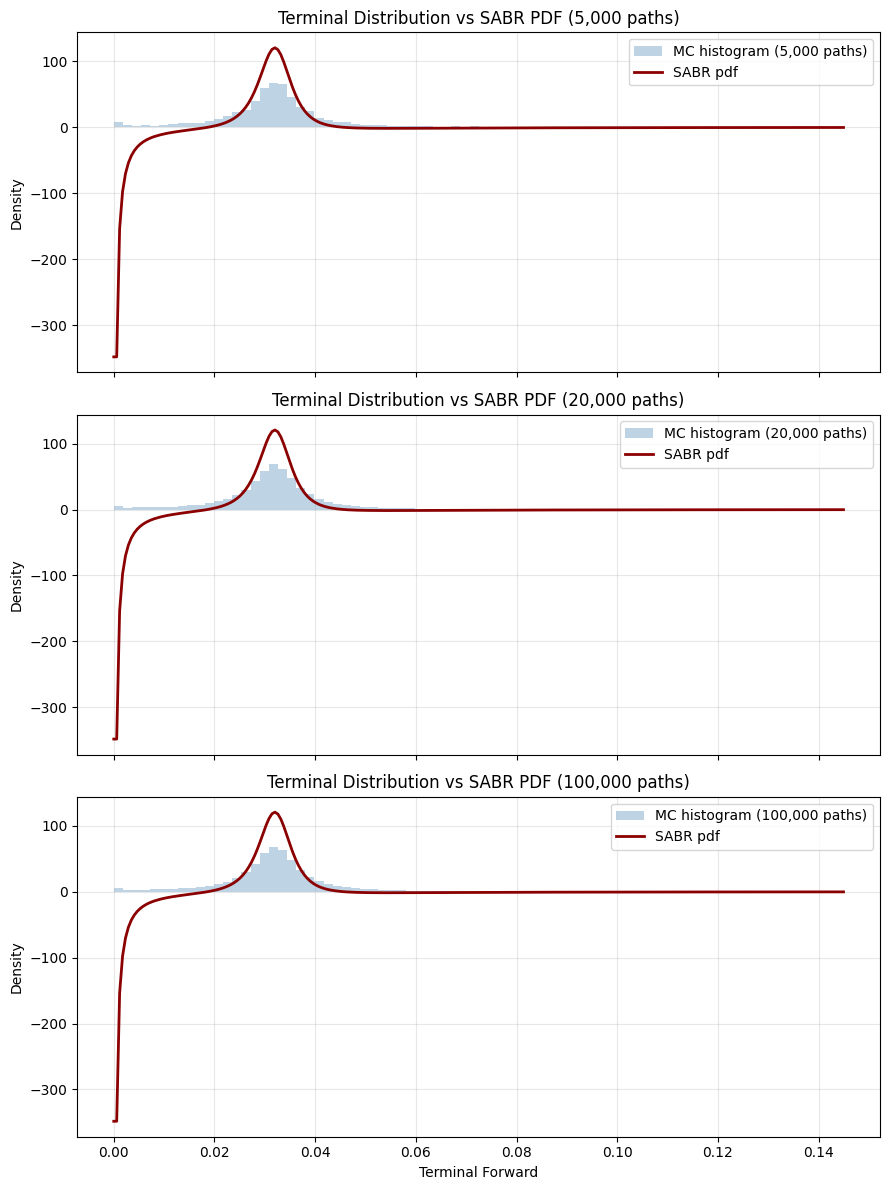

,num_paths,num_steps,dt,mean_terminal_forward,std_terminal_forward,l1_error_vs_pdf,l2_error_vs_pdf
0,5000,1000,0.01,0.032317,0.025436,1.143142,8.923312
1,20000,1000,0.01,0.033877,0.120856,1.120280,8.862489
2,100000,1000,0.01,0.033576,0.135319,1.116090,8.858324


In [19]:
# 4) Monte Carlo terminal distribution vs SABR pdf, and convergence with path count
summary_rows = []
fig, axes = plt.subplots(len(path_list), 1, figsize=(9, 4 * len(path_list)), sharex=True)
if len(path_list) == 1:
    axes = [axes]

for ax, n_paths in zip(axes, path_list):
    sim_res = SABRAnalytics.simulate_terminal_distribution(
        forward=forward,
        time_to_expiry=tte,
        alpha=alpha,
        beta=beta,
        rho=rho,
        nu=nu,
        step_size=step_size,
        num_paths=n_paths,
        shift=shift,
        seed=seed,
    )
    terminal = np.asarray(sim_res["terminal_forward"], dtype=float)

    hist_density, bin_edges = np.histogram(
        terminal,
        bins=80,
        range=(grid_min, grid_max),
        density=True,
    )
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    analytic_on_bins = np.interp(bin_centers, pdf_grid, analytic_pdf)

    l1_err = np.trapezoid(np.abs(hist_density - analytic_on_bins), bin_centers)
    l2_err = np.sqrt(np.trapezoid((hist_density - analytic_on_bins) ** 2, bin_centers))


    summary_rows.append(
        {
            "num_paths": n_paths,
            "num_steps": sim_res["num_steps"],
            "dt": sim_res["dt"],
            "mean_terminal_forward": terminal.mean(),
            "std_terminal_forward": terminal.std(ddof=1),
            "l1_error_vs_pdf": l1_err,
            "l2_error_vs_pdf": l2_err,
        }
    )

    ax.hist(
        terminal,
        bins=80,
        range=(grid_min, grid_max),
        density=True,
        alpha=0.35,
        color="steelblue",
        label=f"MC histogram ({n_paths:,} paths)",
    )
    ax.plot(pdf_grid, analytic_pdf, color="darkred", lw=2, label="SABR pdf")
    ax.set_title(f"Terminal Distribution vs SABR PDF ({n_paths:,} paths)")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Terminal Forward")
plt.tight_layout()
plt.show()

df_convergence = pd.DataFrame(summary_rows)
display(df_convergence)


# 4. Quantile Map


In [ ]:
# Q4 parameters from assignment
S1_0 = 0.03
sigmaN1 = 0.01
beta1 = 0.5
nu1 = 0.2
rho1 = 0.25

S2_0 = 0.05
sigmaN2 = 0.012
beta2 = 0.5
nu2 = 0.15
rho2 = 0.45

corr_12 = 0.9
K = 0.001
T = 10.0

#I generate a new file called quantile_map_pricer.py
for n in [2048, 8192, 32768, 131072]:
    res = qfSABRQuantileMapSpreadOptionFromNormalATM(
        forward_1=S1_0,
        sigma_atm_normal_1=sigmaN1,
        beta_1=beta1,
        rho_1=rho1,
        nu_1=nu1,
        forward_2=S2_0,
        sigma_atm_normal_2=sigmaN2,
        beta_2=beta2,
        rho_2=rho2,
        nu_2=nu2,
        corr_12=corr_12,
        strike=K,
        time_to_expiry=T,
        num_paths=n,
        shift_1=0.0,
        shift_2=0.0,
        num_grid=801,
        seed=42,
        use_sobol=True,
        return_paths=False,
    )
    print(n, "price=", res["price"], "stderr=", res["std_error"])


2048 price= 0.0010878652501994674 stderr= 0.0001739649773308528
8192 price= 0.0010899980505006419 stderr= 8.578226508853909e-05
32768 price= 0.0010899760123400416 stderr= 4.376508503811979e-05
131072 price= 0.0010912475499295804 stderr= 2.2029534992915395e-05


# One Extra Problem

## 1.1 Show $(C)$ is not positive semi-definite

Given
$$
C=
\begin{bmatrix}
1 & 0.9 & 0.9\\
0.9 & 1 & -0.9\\
0.9 & -0.9 & 1
\end{bmatrix}.
$$

Show that $C$ is not positive semi-definite.  
Intuitively, do you see any issues from the correlation matrix $C$?


### Answer

To show $C$ is not positive semi-definite (PSD), it is enough to show it has a negative eigenvalue (equivalently, a negative determinant for this $3\times3$ symmetric case).

For a $3\times3$ correlation matrix:
$$
\det(C)=1+2\rho_{12}\rho_{13}\rho_{23}-\rho_{12}^2-\rho_{13}^2-\rho_{23}^2.
$$

Here,
$$
\rho_{12}=0.9,\quad \rho_{13}=0.9,\quad \rho_{23}=-0.9.
$$
So
$$
\det(C)
=1+2(0.9)(0.9)(-0.9)-0.9^2-0.9^2-(-0.9)^2
=1-1.458-2.43
=-2.888<0.
$$

Hence $C$ is **not PSD**.

Equivalent eigenvalue check:
$$
\lambda(C)=\{1.9,\;1.9,\;-0.8\},
$$
so one eigenvalue is negative.

**Intuition:**  
This correlation structure is inconsistent: variable 1 is strongly positively correlated with both variables 2 and 3, yet variables 2 and 3 are strongly negatively correlated. Such pairwise constraints cannot be embedded into a valid joint correlation matrix.


## 1.2 Prove the Generator Is PSD

Given the correlation generator
$$
\rho(i,j;\eta,\lambda)=\eta+(1-\eta)e^{-\lambda|T_i-T_j|},\quad \forall i,j,
$$
where $T_i,T_j$ are terms and $\eta,\lambda\ge 0$.

Prove that the matrix $[\rho_{ij}]$ is positive semi-definite.

**Hint:**
- It suffices to prove that for any coefficients $\{a_i\}$,
  $$
  \sum_{i,j} a_i a_j \rho_{ij}\ge 0.
  $$
- For $\lambda>0$,
  $$
  e^{-\lambda|x|}=\frac{2\lambda}{\pi}\int_0^\infty \frac{\cos(wx)}{\lambda^2+w^2}\,dw.
  $$


### Answer

Define
$$
\rho_{ij}=\eta+(1-\eta)e^{-\lambda|T_i-T_j|}.
$$
To prove $[\rho_{ij}]$ is PSD, it is enough to show that for any real vector $a=(a_1,\dots,a_n)$,
$$
\sum_{i,j}a_i a_j \rho_{ij}\ge 0.
$$

Compute:
$$
\sum_{i,j}a_i a_j \rho_{ij}
=
\eta\sum_{i,j}a_i a_j
+
(1-\eta)\sum_{i,j}a_i a_j e^{-\lambda|T_i-T_j|}.
$$
So
$$
\sum_{i,j}a_i a_j \rho_{ij}
=
\eta\left(\sum_i a_i\right)^2
+
(1-\eta)\sum_{i,j}a_i a_j e^{-\lambda|T_i-T_j|}.
$$

The first term is nonnegative if $\eta\ge 0$.

For the second term, use the given identity (for $\lambda>0$):
$$
e^{-\lambda|x|}
=
\frac{2\lambda}{\pi}\int_0^\infty
\frac{\cos(wx)}{\lambda^2+w^2}\,dw.
$$
Hence
$$
\sum_{i,j}a_i a_j e^{-\lambda|T_i-T_j|}
=
\frac{2\lambda}{\pi}\int_0^\infty
\frac{1}{\lambda^2+w^2}
\sum_{i,j}a_i a_j\cos\!\big(w(T_i-T_j)\big)\,dw.
$$
Now use
$$
\cos(u-v)=\cos u\cos v+\sin u\sin v,
$$
so
$$
\sum_{i,j}a_i a_j\cos\!\big(w(T_i-T_j)\big)
=
\left(\sum_i a_i\cos(wT_i)\right)^2
+
\left(\sum_i a_i\sin(wT_i)\right)^2
\ge 0.
$$
Also
$$
\frac{2\lambda}{\pi}\frac{1}{\lambda^2+w^2}\ge 0.
$$
Therefore the integral is nonnegative, so
$$
\sum_{i,j}a_i a_j e^{-\lambda|T_i-T_j|}\ge 0.
$$

If $0\le \eta\le 1$, then $(1-\eta)\ge 0$, so both terms are nonnegative and thus
$$
\sum_{i,j}a_i a_j \rho_{ij}\ge 0.
$$
Therefore $[\rho_{ij}]$ is PSD.

So the generator is PSD for $\lambda\ge 0$ and $0\le\eta\le 1$ (the usual correlation-parameter range).


## 1.3 Find the Closest Positive Semi-Definite Matrix to $C$

Find the “closest” positive semi-definite matrix to
$$
C=
\begin{bmatrix}
1 & 0.9 & 0.9\\
0.9 & 1 & -0.9\\
0.9 & -0.9 & 1
\end{bmatrix}.
$$

**Hint:**
- Use Python `np.linalg.norm` and `scipy.minimize`.
- Optimize with Frobenius norm:
  $$
  \|\rho-C\|_F^2.
  $$


### Answer 1.3

For
$$
C=
\begin{bmatrix}
1 & 0.9 & 0.9\\
0.9 & 1 & -0.9\\
0.9 & -0.9 & 1
\end{bmatrix},
$$
the nearest PSD matrix under Frobenius norm is the projection of $C$ onto the PSD cone.

1. Eigendecompose:
$$
C = Q\Lambda Q^\top,\qquad
\Lambda=\operatorname{diag}(-0.8,\,1.9,\,1.9).
$$

2. Clip negative eigenvalues to zero:
$$
\Lambda_+ = \operatorname{diag}(0,\,1.9,\,1.9).
$$

3. Reconstruct:
$$
C_{\text{PSD}}=Q\Lambda_+Q^\top
=
\begin{bmatrix}
1.26666667 & 0.63333333 & 0.63333333\\
0.63333333 & 1.26666667 & -0.63333333\\
0.63333333 & -0.63333333 & 1.26666667
\end{bmatrix}.
$$

So the closest PSD matrix is
$$
\boxed{
\begin{bmatrix}
1.26666667 & 0.63333333 & 0.63333333\\
0.63333333 & 1.26666667 & -0.63333333\\
0.63333333 & -0.63333333 & 1.26666667
\end{bmatrix}
}.
$$

Distance:
$$
\|C_{\text{PSD}}-C\|_F=0.8,\qquad
\|C_{\text{PSD}}-C\|_F^2=0.64.
$$


In [21]:
import numpy as np

C = np.array([
    [1.0, 0.9, 0.9],
    [0.9, 1.0, -0.9],
    [0.9, -0.9, 1.0]
])

w, Q = np.linalg.eigh(C)
w_pos = np.clip(w, 0.0, None)
C_psd = Q @ np.diag(w_pos) @ Q.T

print("eigvals(C):", w)
print("closest PSD matrix:\n", C_psd)
print("||C_psd - C||_F^2 =", np.linalg.norm(C_psd - C, "fro")**2)


eigvals(C): [-0.8  1.9  1.9]
closest PSD matrix:
 [[ 1.26666667  0.63333333  0.63333333]
 [ 0.63333333  1.26666667 -0.63333333]
 [ 0.63333333 -0.63333333  1.26666667]]
||C_psd - C||_F^2 = 0.6400000000000002
